In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
%load_ext autoreload
%autoreload 2

from package.data import *
from package.model import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# data tests

In [35]:
df = pd.read_csv('../data/format_data.csv')

## process_to_triangle

In [36]:
# notebook extract
data = df.copy()

data = data.rename(columns={'Delay': 'delay'}).drop(columns=['CLASSI_FIN', 'EVOLUCAO', 'CO_MUN_RES'])
data['date_onset']  = pd.to_datetime(data['date_onset'])
data['date_report'] = pd.to_datetime(data['date_report'])

D = 10
n_before = len(data)
data = data[data['delay'] <= D].copy()
print(f"\nKept {len(data)} / {n_before} cases with Delay ≤ {D} "
      f"({100*len(data)/n_before:.1f}%)")

data = data.rename(columns={'delay':'d', 'date_onset':'date'})
counts = (data.groupby(['date', 'd']).size().reset_index(name='n_td'))
all_dates = pd.date_range(counts['date'].min(), counts['date'].max(), freq='W-MON')
grid = pd.MultiIndex.from_product([all_dates, range(D + 1)],names=['date', 'd']).to_frame(index=False)
data = grid.merge(counts, on=['date', 'd'], how='left').fillna({'n_td': 0})

data['t'] = data['date'].rank(method='dense').astype(int)
data['week_of_year'] = data['date'].dt.isocalendar().week.astype(int)
data.loc[data['week_of_year'] == 53, 'week_of_year'] = 52

data = data[['date', 't', 'd', 'week_of_year', 'n_td']]
data['n_td'] = data['n_td'].astype(int)


Kept 60749 / 65366 cases with Delay ≤ 10 (92.9%)


In [37]:
data

,date,t,d,week_of_year,n_td
0,2019-12-23,1,0,52,0
1,2019-12-23,1,1,52,1
2,2019-12-23,1,2,52,0
3,2019-12-23,1,3,52,1
4,2019-12-23,1,4,52,0
...,...,...,...,...,...
1293,2022-03-21,118,6,12,0
1294,2022-03-21,118,7,12,0
1295,2022-03-21,118,8,12,0
1296,2022-03-21,118,9,12,0


In [38]:
# package function
data = df.copy()

data = process_to_triangle(data, 10)
data
export(data, 'modelling_data')


Kept 60749 / 65366 cases with Delay ≤ 10, 92.9%
executed, file modelling_data saved to /Users/dg/Desktop/DG/university/exeter/files/modules/projects : dissertation/coding/data/modelling_data.csv.csv


## to_mem_format

In [14]:
# pacakge function

data = df.copy()
data = process_to_triangle(data, 10)

data = to_mem_format(data, date_col='date', value_col='n_td')
data


Kept 60749 / 65366 cases with Delay ≤ 10, 92.9%


,Season_2020,Season_2021
epiweek,,
1,17.0,760.0
2,21.0,693.0
3,18.0,621.0
4,27.0,500.0
5,17.0,585.0
6,18.0,520.0
7,23.0,667.0
8,21.0,781.0
9,46.0,1319.0


## mem_labels

In [33]:
# package function
data = df.copy()
data = process_to_triangle(df, 10)
data = mem_and_phase_labels(data, 764.83, 1388.52, 1625.79)


Kept 60749 / 65366 cases with Delay ≤ 10, 92.9%


In [34]:
data[['regime', 'phase']].value_counts()

regime    phase    
baseline  declining    53
          rising       36
moderate  rising       13
          declining    10
baseline  stable        4
high      rising        2
Name: count, dtype: int64

# model_tests

In [ ]:
import os

## create_and_train_gam

In [69]:
# package function
r_path    = os.path.abspath('../gam_model.r')
data_path = os.path.abspath('../data/modelling_data.csv')

pred, ci, posterior = create_and_train_gam(r_path, data_path, 40)

/Users/dg/Desktop/DG/university/exeter/files/modules/projects : dissertation/coding/gam_model.r finished successfully


In [70]:
pred

,date,t,d,week_of_year,n_td,n_td_true,observed,pred
0,2019-12-23,1,0,52,0.0,0,True,0.180550
1,2019-12-23,1,1,52,1.0,1,True,2.179116
2,2019-12-23,1,2,52,0.0,0,True,2.694882
3,2019-12-23,1,3,52,1.0,1,True,1.659343
4,2019-12-23,1,4,52,0.0,0,True,1.081311
...,...,...,...,...,...,...,...,...
435,2020-09-21,40,6,39,NaN,10,False,30.149863
436,2020-09-21,40,7,39,NaN,17,False,22.773472
437,2020-09-21,40,8,39,NaN,8,False,20.419161
438,2020-09-21,40,9,39,NaN,6,False,14.859424


In [71]:
ci

,date,N_hat,N_lo,N_hi
0,2019-12-23,2.000,2.000,2.000
1,2019-12-30,17.000,17.000,17.000
2,2020-01-06,21.000,21.000,21.000
3,2020-01-13,18.000,18.000,18.000
4,2020-01-20,27.000,27.000,27.000
5,2020-01-27,17.000,17.000,17.000
6,2020-02-03,18.000,18.000,18.000
7,2020-02-10,23.000,23.000,23.000
8,2020-02-17,21.000,21.000,21.000
9,2020-02-24,46.000,46.000,46.000


In [72]:
posterior

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V991,V992,V993,V994,V995,V996,V997,V998,V999,V1000
2019-12-23,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
2019-12-30,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
2020-01-06,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,21,21,21,21,21
2020-01-13,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
2020-01-20,27,27,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
2020-01-27,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
2020-02-03,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
2020-02-10,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
2020-02-17,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,21,21,21,21,21
2020-02-24,46,46,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,46,46


## create_and_train_inla

In [80]:
# package function
r_path    = os.path.abspath('../inla_model.r')
data_path = os.path.abspath('../data/modelling_data.csv')

pred, posterior = create_and_train_inla(r_path, data_path, 40)

/Users/dg/Desktop/DG/university/exeter/files/modules/projects : dissertation/coding/inla_model.r finished successfully


In [81]:
pred

,date,t,d,week_of_year,n_td,n_td_true,observed,Y,Time,Delay,Time2,Delay2,WeekOfYear,pred
0,2019-12-23,1,0,52,0.0,0,True,0.0,1,0,1,1,52,0.000
1,2019-12-23,1,1,52,1.0,1,True,1.0,1,1,1,2,52,1.000
2,2019-12-23,1,2,52,0.0,0,True,0.0,1,2,1,3,52,0.000
3,2019-12-23,1,3,52,1.0,1,True,1.0,1,3,1,4,52,1.000
4,2019-12-23,1,4,52,0.0,0,True,0.0,1,4,1,5,52,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,2020-09-21,40,6,39,NaN,10,False,NaN,40,6,40,7,39,25.206
436,2020-09-21,40,7,39,NaN,17,False,NaN,40,7,40,8,39,12.097
437,2020-09-21,40,8,39,NaN,8,False,NaN,40,8,40,9,39,8.882
438,2020-09-21,40,9,39,NaN,6,False,NaN,40,9,40,10,39,6.068


In [82]:
posterior

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V991,V992,V993,V994,V995,V996,V997,V998,V999,V1000
2019-12-23,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
2019-12-30,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
2020-01-06,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,21,21,21,21,21
2020-01-13,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
2020-01-20,27,27,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
2020-01-27,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
2020-02-03,18,18,18,18,18,18,18,18,18,18,...,18,18,18,18,18,18,18,18,18,18
2020-02-10,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
2020-02-17,21,21,21,21,21,21,21,21,21,21,...,21,21,21,21,21,21,21,21,21,21
2020-02-24,46,46,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,46,46


# workflow

In [159]:
df = pd.read_csv('../data/format_data.csv')

In [160]:
# create run-off triangle
data = process_to_triangle(df, 10)

# MEM data format + export to csv
mem_data = to_mem_format(data, date_col='date', value_col='n_td')
export(mem_data, 'mem_data')
# MEM inference
run_mem('mem_model.r', 'mem_data.csv', 'sari')


Kept 60749 / 65366 cases with Delay ≤ 10, 92.9%
executed, file mem_data saved to /Users/dg/Desktop/DG/university/exeter/files/modules/projects : dissertation/coding/data/mem_data.csv
/Users/dg/Desktop/DG/university/exeter/files/modules/projects : dissertation/coding/mem_model.r finished successfully


,epi$intensity.thresholds
0,971.714666
1,1388.516946
2,1625.793508


In [161]:
# MEM labels
data = mem_and_phase_labels(data, 971.714666, 1388.52, 1625.79)

# Cutoff selection
cutoff = select_cutoffs(data)

In [233]:
data

,date,t,d,week_of_year,n_td,regime,phase
0,2019-12-23,1,0,52,0,baseline,stable
1,2019-12-23,1,1,52,1,baseline,stable
2,2019-12-23,1,2,52,0,baseline,stable
3,2019-12-23,1,3,52,1,baseline,stable
4,2019-12-23,1,4,52,0,baseline,stable
...,...,...,...,...,...,...,...
1293,2022-03-21,118,6,12,0,baseline,declining
1294,2022-03-21,118,7,12,0,baseline,declining
1295,2022-03-21,118,8,12,0,baseline,declining
1296,2022-03-21,118,9,12,0,baseline,declining


In [162]:
cutoff

,date,t,regime,phase
0,2020-07-13,30,baseline,declining
1,2020-08-24,36,baseline,rising
2,2021-03-01,63,moderate,rising
3,2021-03-08,64,high,rising
4,2021-03-22,66,moderate,declining


In [ ]:
# cutoff 1
gam_pred, gam_ci, gam_posterior = create_and_train_gam(r_path='gam_model.r', data_path='untrimmed_data.csv', cutoff=30)
inla_pred, inla_posterior = create_and_train_inla(r_path='inla_model.r', data_path='untrimmed_data.csv', cutoff=30)

/Users/dg/Desktop/DG/university/exeter/files/modules/projects : dissertation/coding/gam_model.r finished successfully


Poor performing GAM
  - Overly global, not sensitive enough to local shocks
  - Overly penalised

Change:
  - Tried adaptive smooth (bs='ad')
    - Allows the penalty to vary locally, however K needs to be higher for it to work properly. Issue is that K is limited by the DOF (there are only 10 unique values for d (delay))
    - t alone with (bs='ad') and higher K does not make enough impact
  - Tried gaussian process smooth (bs='gp')
    - Specifies how quickly smooth can change through argument m.
      - M[0] chooses the smoothness class (higher more smooth)
      - M[1] chooses the independence in scale from covariate (higher the bigger the distance before independence)
  - **Tried p-spline (bs='ps')**
    - The P-spline penalises differences between adjacent coefficients rather than second derivatives
    - This is what RW1 does in the INLA model, this week = last week + noise
  - Including a lag term **NOT TRIED**
    - Take the previous value within
  - Changing gammma to < 1
    - Didn't make much difference when cutoff = 30
  - Weighting recent weeks more heavily **NOT TRIED**
    - Recent observations are more reliable and important than older ones

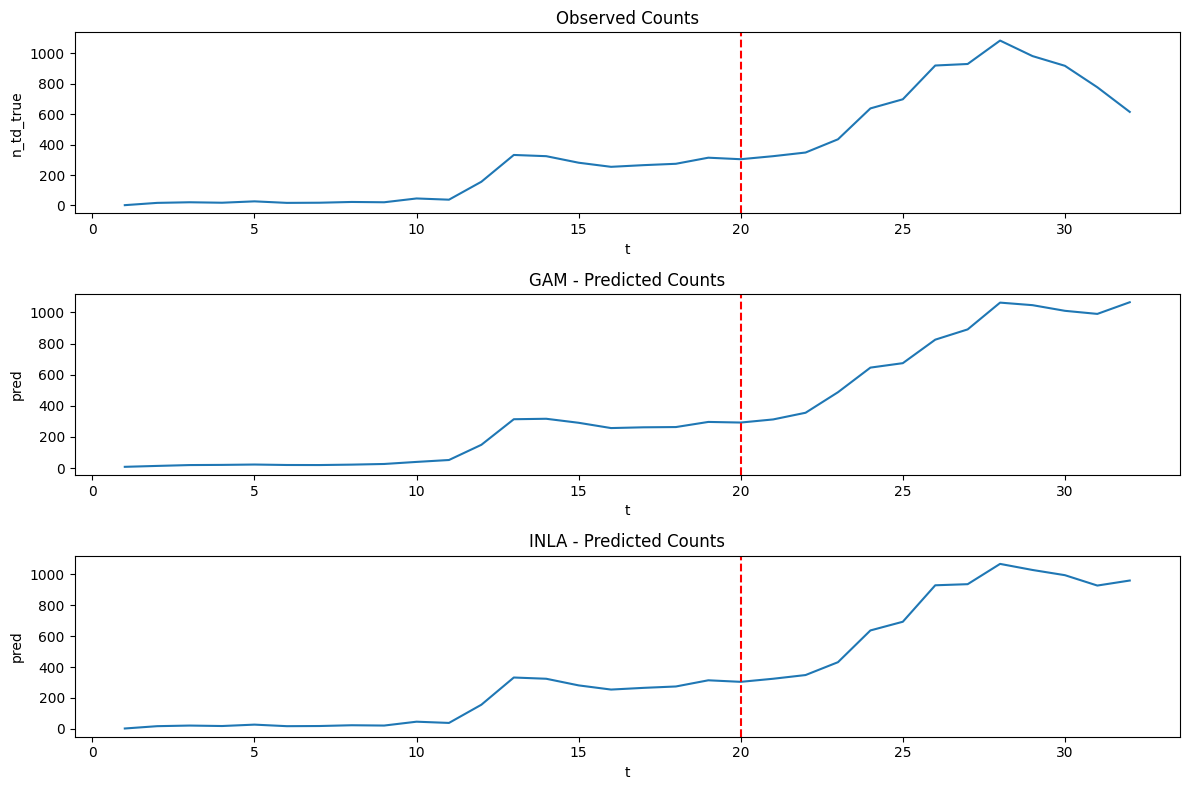

In [312]:
gam_viz = gam_pred.groupby('t').agg({'n_td_true':'sum', 'pred':'sum'})
inla_viz = inla_pred.groupby('t').agg({'n_td_true':'sum', 'pred':'sum'})

fig, ax = plt.subplots(3, 1, figsize=(12, 8))

sns.lineplot(gam_viz, x='t', y='n_td_true', ax=ax[0])
ax[0].set_title('Observed Counts')
ax[0].axvline(20, color='red', linestyle='--')

sns.lineplot(gam_viz, x='t', y='pred', ax=ax[1])
ax[1].set_title('GAM - Predicted Counts')
ax[1].axvline(20, color='red', linestyle='--')

sns.lineplot(inla_viz, x='t', y='pred', ax=ax[2])
ax[2].set_title('INLA - Predicted Counts')
ax[2].axvline(20, color='red', linestyle='--')

plt.tight_layout()